Record 0 → 3971 points


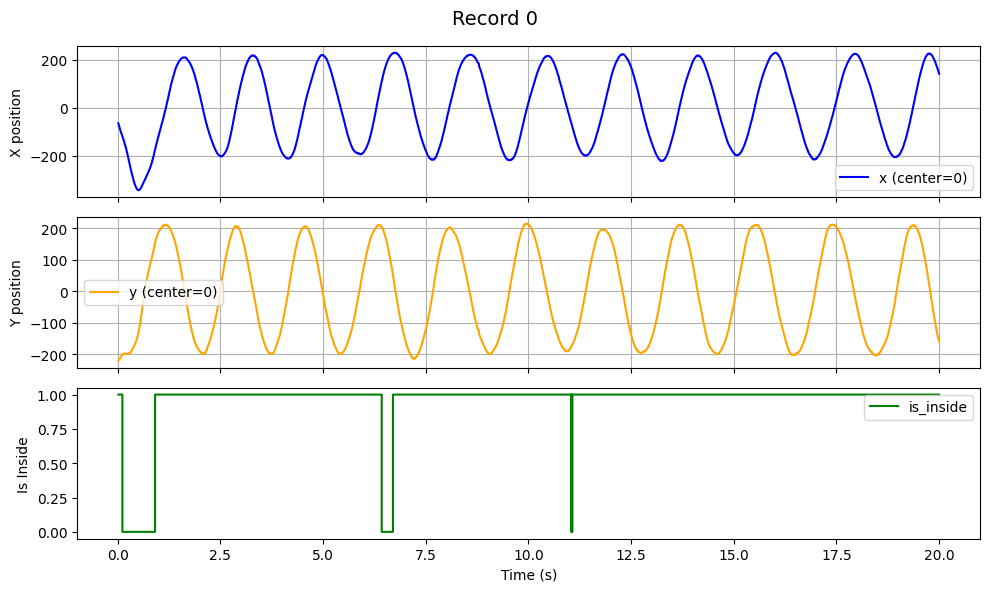

Record 1 → 3898 points


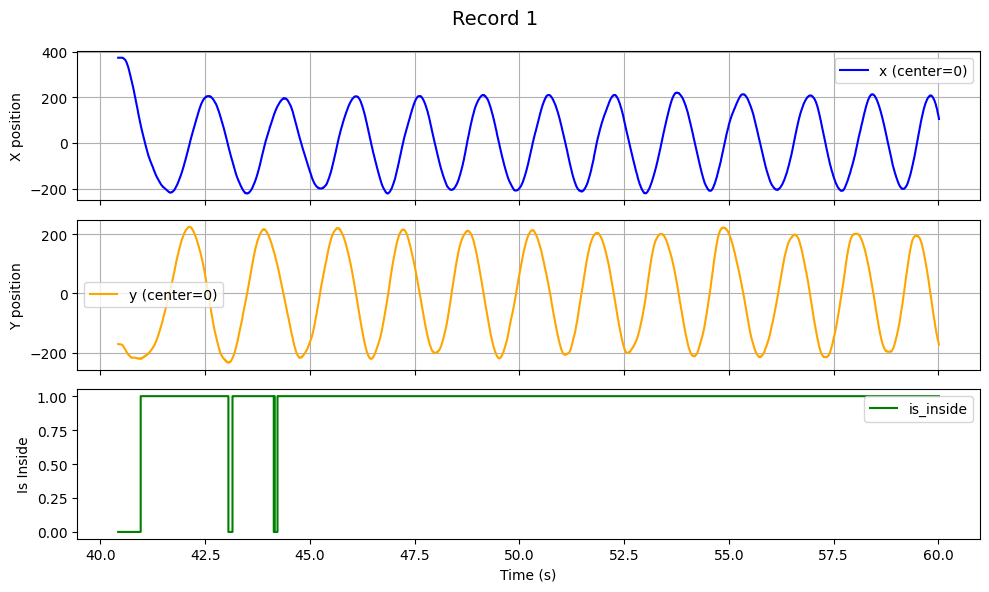

Record 2 → 3898 points


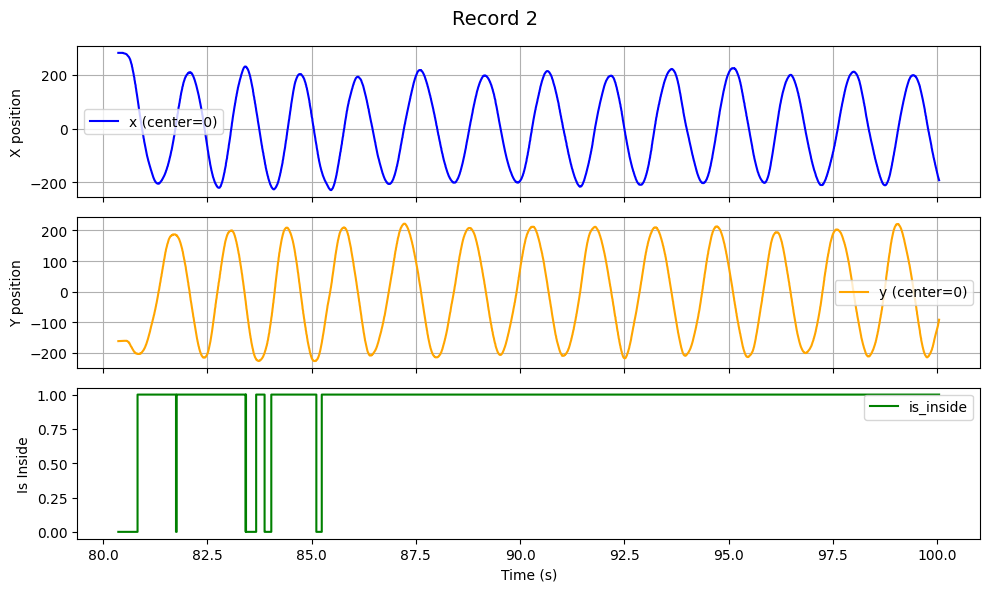

Record 3 → 3884 points


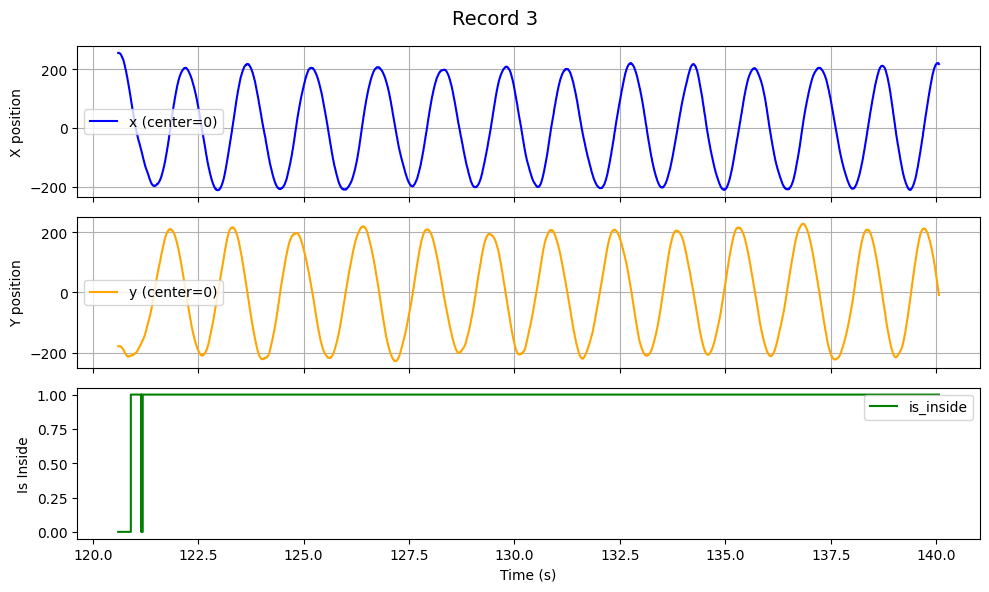

Record 4 → 3936 points


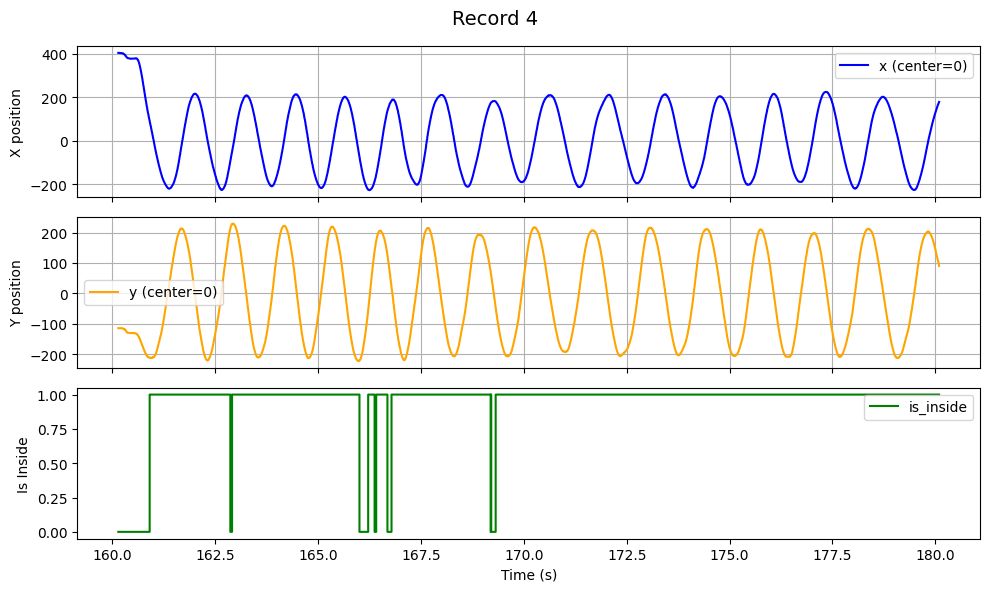

Record   nLaps       Re       Te   error%   MT/lap    IDe/lap       Be      IPe
Rec001  10.84   213.86    22.21     5.39     1.84       4.27     0.45     2.31
Rec002  12.09   212.99    23.75     3.21     1.62       4.17     0.46     2.57
Rec003  13.35   210.66    14.67     4.34     1.47       4.84     0.43     3.29
Rec004  12.91   210.45    12.57     1.49     1.51       5.07     0.45     3.36
Rec005  14.88   214.14    25.29     4.93     1.34       4.08     0.38     3.04


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO

# 1. Code Denis.Mottet
def read_markers(fname):
    markers_dict = {
        "time_stamp": np.array([], dtype=float),
        "label": np.array([], dtype=str),
        "fname": fname,
    }

    def add_marker(time_stamp, label):
        markers_dict["time_stamp"] = np.append(markers_dict["time_stamp"], time_stamp)
        markers_dict["label"] = np.append(markers_dict["label"], label)

    def add_multiline_marker(multiline_time_stamp, multiline_label):
        if multiline_label.endswith("\n"):
            multiline_label = multiline_label[:-1]
        add_marker(multiline_time_stamp, multiline_label)

    with open(fname, "r") as f:
        for line in f:
            if line.strip() == "":
                break

        multiline_mode = False
        multiline_label = ""
        multiline_time_stamp = np.nan

        for line in f:
            if multiline_mode:
                if line.strip() == "":
                    add_multiline_marker(multiline_time_stamp, multiline_label)
                    multiline_mode = False
                else:
                    multiline_label += line
                continue

            items = line.strip().split(",")
            time_stamp = float(items[1])
            label = items[2]
            if label == "":
                multiline_time_stamp = time_stamp
                multiline_label = ""
                multiline_mode = True
            else:
                add_marker(time_stamp, label)

        if multiline_mode:
            add_multiline_marker(multiline_time_stamp, multiline_label)

    return markers_dict

# -----------------------------
# 2. Lecture des données CSV (UNE SEULE FOIS)
# -----------------------------
fname_csv = "../data/001MoDe_R1.csv"
fname_marker = "../data/001MoDe_R1.marker.csv"

def is_numeric_line(line):
    try:
        [float(x) for x in line.strip().split(",")]
        return True
    except:
        return False

with open(fname_csv, "r") as f:
    rows = [line for line in f if is_numeric_line(line)]

data = np.loadtxt(StringIO("".join(rows)), delimiter=",")

time_ms = data[:, 0]
x = data[:, 1]
y = data[:, 2]
is_inside_csv = data[:, 3].astype(bool)  # 4ème colonne du CSV

# -----------------------------
# 3. Lecture des markers pour trouver le premier DoRecord
# -----------------------------
markers = read_markers(fname_marker)
do_record_times = markers["time_stamp"][np.char.startswith(markers["label"], "DoCycleChange:DoRecord")]
t0 = do_record_times[0]

# Temps relatif en secondes
time = (time_ms - t0) / 1000.0

# -----------------------------
# 4. Paramètres de la tâche
# -----------------------------
centerX, centerY = 552.0, 330.0
cornerX, cornerY = 302.0, 80.0
taskRadius, taskTolerance = 209.5, 47.0

# Recentrer le repère : centre du cercle = (0,0)
x = x - centerX
y = y - centerY

# Calcul de la distance
dist = np.sqrt(x**2 + y**2)

# -----------------------------
# 5. Intervalles des records (en secondes relatives)
# -----------------------------
record_intervals = [
    (0.004, 20.007),
    (40.011, 60.022),
    (80.043, 100.057),
    (120.061, 140.075),
    (160.090, 180.104)
]

# -----------------------------
# 6. Tracer les graphes pour chaque record
# -----------------------------
for i, (start, end) in enumerate(record_intervals):
    mask = (time >= start) & (time <= end)
    t = time[mask]
    x_rec = x[mask]
    y_rec = y[mask]
    inside_rec = is_inside_csv[mask].astype(int)

    print(f"Record {i} → {mask.sum()} points")

    fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(f"Record {i}", fontsize=14)

    axs[0].plot(t, x_rec, 'b-', label='x (center=0)')
    axs[0].set_ylabel("X position")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(t, -y_rec, 'orange', label='y (center=0)')
    axs[1].set_ylabel("Y position")
    axs[1].legend()
    axs[1].grid(True)

    axs[2].step(t, inside_rec, where='post', color='green', label='is_inside')
    axs[2].set_ylabel("Is Inside")
    axs[2].set_xlabel("Time (s)")
    axs[2].legend()

    plt.tight_layout()
    plt.show()

# -----------------------------
# 7. Fonction de calcul des métriques (CORRIGÉE)
# -----------------------------
def compute_metrics(t, x, y, dist, is_inside):
    # Re = rayon effectif
    Re = np.mean(dist)

    # Te = tolérance effective
    Te = np.std(dist)

    # erreur (%) = points hors cible (UTILISE is_inside du CSV)
    error = np.sum(~is_inside) / len(is_inside) * 100

    # 🧭 Estimation des tours via variation angulaire
    theta = np.arctan2(y, x)
    dtheta = np.diff(theta)
    dtheta = (dtheta + np.pi) % (2 * np.pi) - np.pi
    total_angle = np.sum(np.abs(dtheta))
    nLaps = total_angle / (2 * np.pi)

    # MT/lap = durée / nLaps
    duration = t[-1] - t[0]
    MT = duration / nLaps if nLaps > 0 else np.nan

    # IDe/lap = log2(2 * Re / Te)
    IDe = np.log2(2 * Re / Te) if Te > 0 else np.nan

    # IPe = IDe / MT
    IPe = IDe / MT if MT > 0 else np.nan

    # Be = nombre de changements de direction radiale
    dr = np.diff(dist)
    dt = np.diff(t)
    dt[dt < 1e-6] = np.nan
    vr = dr / dt
    zero_crossings = np.sum(np.diff(np.sign(vr)) != 0)
    Be = zero_crossings / len(dist)

    return nLaps, Re, Te, error, MT, IDe, Be, IPe

# -----------------------------
# 8. Calcul pour chaque record
# -----------------------------
print(f"{'Record':<7} {'nLaps':>6} {'Re':>8} {'Te':>8} {'error%':>8} {'MT/lap':>8} {'IDe/lap':>10} {'Be':>8} {'IPe':>8}")
for i, (start, end) in enumerate(record_intervals):
    mask = (time >= start) & (time <= end)
    t_rec = time[mask]
    x_rec = x[mask]
    y_rec = y[mask]
    dist_rec = dist[mask]
    is_inside_rec = is_inside_csv[mask]
    
    nLaps, Re, Te, error, MT, IDe, Be, IPe = compute_metrics(t_rec, x_rec, y_rec, dist_rec, is_inside_rec)
    print(f"Rec{i+1:03d} {nLaps:6.2f} {Re:8.2f} {Te:8.2f} {error:8.2f} {MT:8.2f} {IDe:10.2f} {Be:8.2f} {IPe:8.2f}")